# Setup & Imports

In [39]:
import pandas as pd

import matplotlib.pyplot as plt

import json

from pathlib import Path

# Load Data

In [60]:
BASE_DIR = Path("../../data/01_raw/R_9346-I_Zulassungskarten")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")

df = pd.DataFrame(metadata)
#print(df)

# Data Cleaning

In [66]:
# convert string to datetime
df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')

# extract year from Datetime and save in extra column
df['Jahr'] = df['Prüfdatum'].dt.year.astype('Int64')


# convert Prüfnummer to number
df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

# sort by Prüfnummer
df = df.sort_values(by='Prüfnummer')

df


,Titel_und_Signatur,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_source_folder,_file_name,Bemerkung,Ort des Prüfdatums,Jahr
79,R 9346-I/1\nDie Wölfin.\n1920 - 1945,2,1920-06-24,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1,R 9346-I_1.json,nach Kürzung 1480 m,NaN,1920
75,R 9346-I/2\nDie Spieler\n1920 - 1945,7,1920-06-25,"Asslan-Film Continental, Berlin","Asslan-Film Continental, Berlin",Deutschland,Spielfilm,Stummfilm,2379,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2,R 9346-I_2.json,NaN,NaN,1920
17,R 9346-I/3\nSowas kommt von Sowas\n1920 - 1945,9,1920-06-24,"Karfiol-Film, Berlin","Karfiol-Film, Berlin",Deutschland,Spielfilm,Stummfilm,505,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_3,R 9346-I_3.json,NaN,NaN,1920
83,R 9346-I/4\nDer Gefangene. (Sklaven des XX. Ja...,11,1920-07-09,"Kowo Gesellschaft, Berlin","Kowo Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,1833,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_4,R 9346-I_4.json,LF260322: Durch Blut und Eisen,NaN,1920
35,R 9346-I/5\nDie entfesselte Menschheit\n1920 -...,20,1920-06-29,"Nivo-Film-Comp. GmbH, Berlin","Nivo-Film-Comp. GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,2453,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_5,R 9346-I_5.json,NaN,NaN,1920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,R 9346-I/118\nDie Spinnen. (Das Brilliantensch...,651,1920-11-03,"Decla-Bioscop AG, Berlin","Decla-Film-Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,2219,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_118,R 9346-I_118.json,NaN,NaN,1920
113,R 9346-I/119\nAugen\n1920 - 1945,660,1921-01-30,"Citograph-Filmgesellschaft mbH, Berlin","Citograph-Film GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,1406,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_119,R 9346-I_119.json,NaN,NaN,1921
37,R 9346-I/120\nDer Vorstadt Caruso\n1920 - 1945,661,1920-10-28,B.B.-Film-Fabrikation,B.B.-Film-Fabrikation,Deutschland,Spielfilm,Stummfilm,1195,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_120,R 9346-I_120.json,NaN,NaN,1920
114,R 9346-I/121\nDie Morphinistin\n1920 - 1945,668,1920-10-29,"Ebert-Film GmbH, Berlin","Ebert-Film GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,1534,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_121,R 9346-I_121.json,NaN,NaN,1920


# Statistical Analysis

## Reconstruction lost Documents

In [62]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1920                   2             669                     668              117                551
 1921                  22             660                     639                5                634


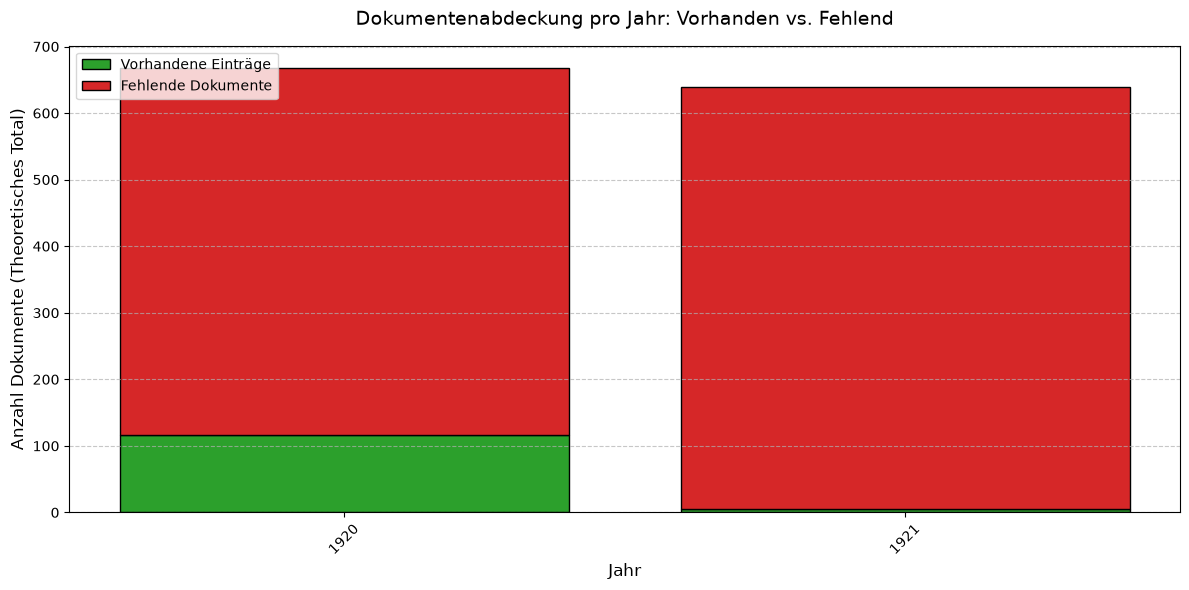

In [63]:


# drop na
plot_df = summary.dropna(subset=['Jahr']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c', # Grün für "OK"
    edgecolor='black'
)

ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728', # Rot für "Fehlt"
    edgecolor='black'
)


ax.set_title('Dokumentenabdeckung pro Jahr: Vorhanden vs. Fehlend', fontsize=14, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anzahl Dokumente (Theoretisches Total)', fontsize=12)

ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(loc='upper left')

plt.tight_layout()

plt.show()

## Decision 

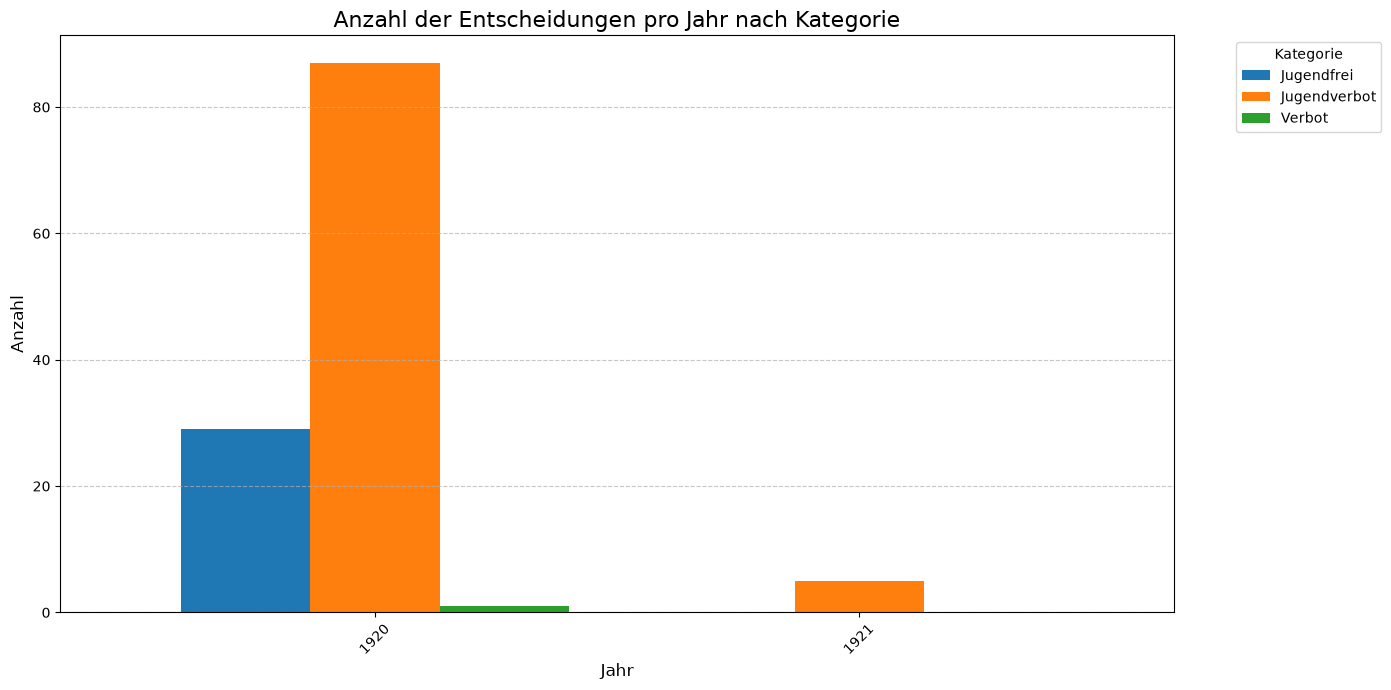

In [64]:
df_grouped = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Entscheidungen pro Jahr nach Kategorie', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


## Filmtypes

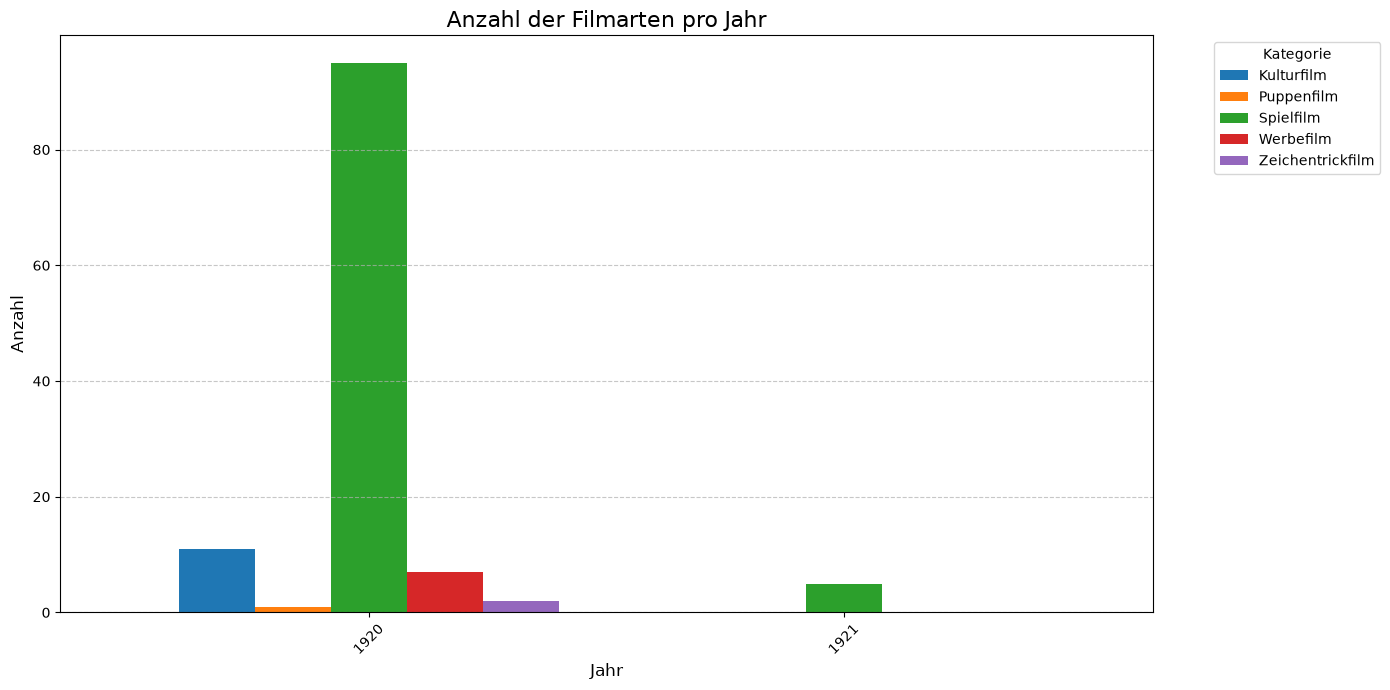

In [68]:
df_grouped = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


##

/tmp/ipykernel_21887/1831885678.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


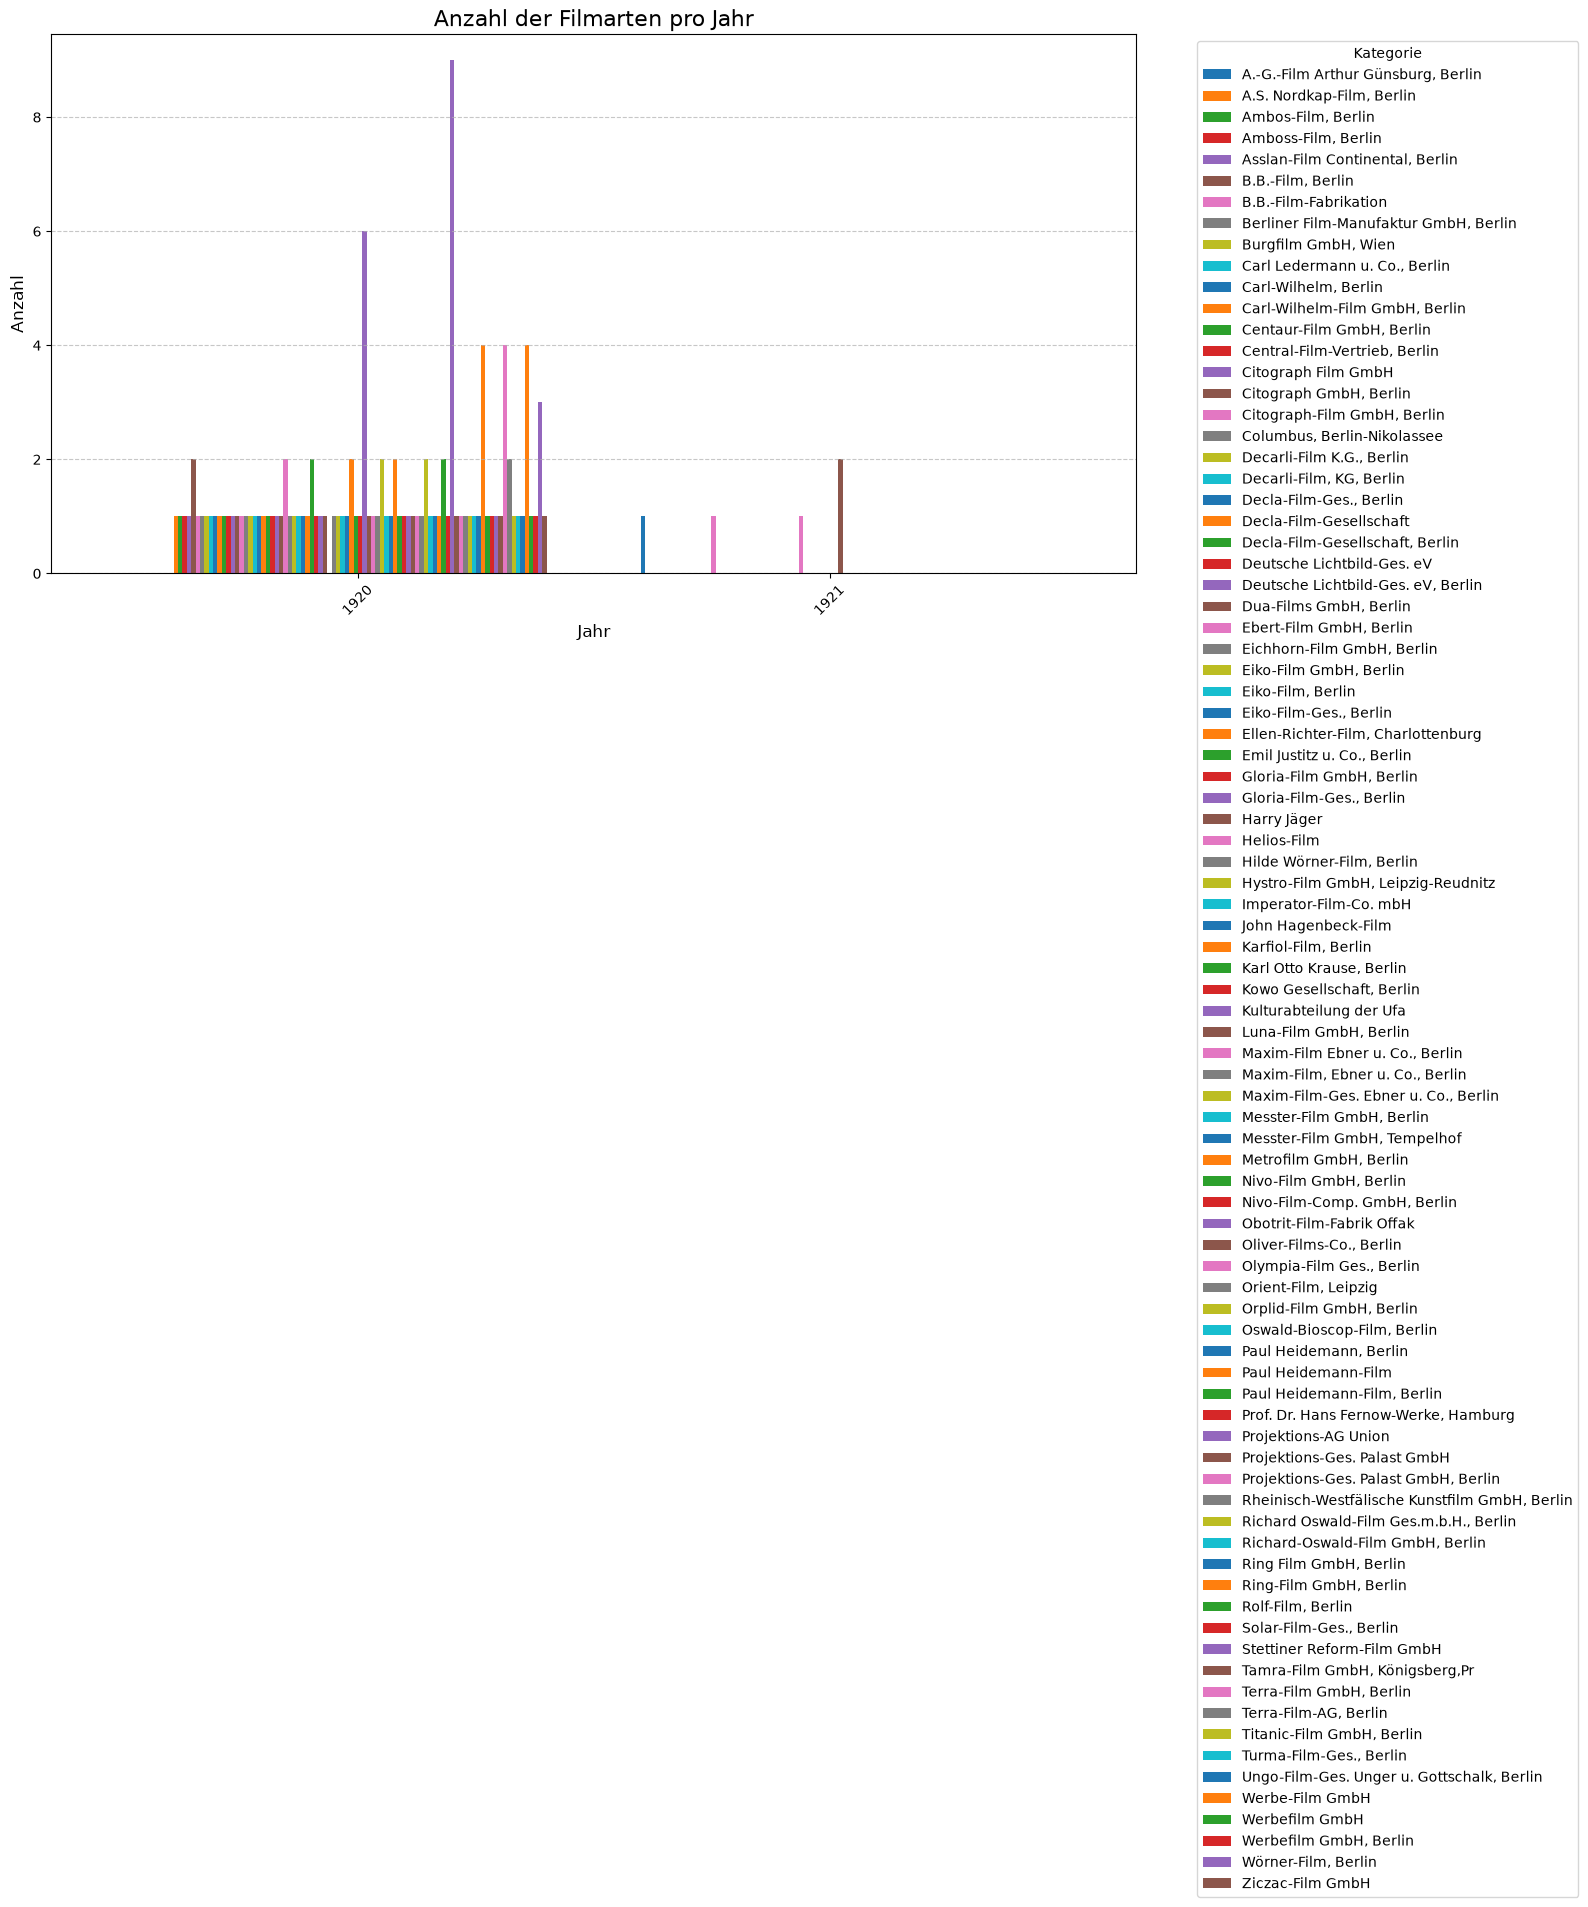

In [73]:
df_grouped = df.groupby(['Jahr', 'Produktion']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


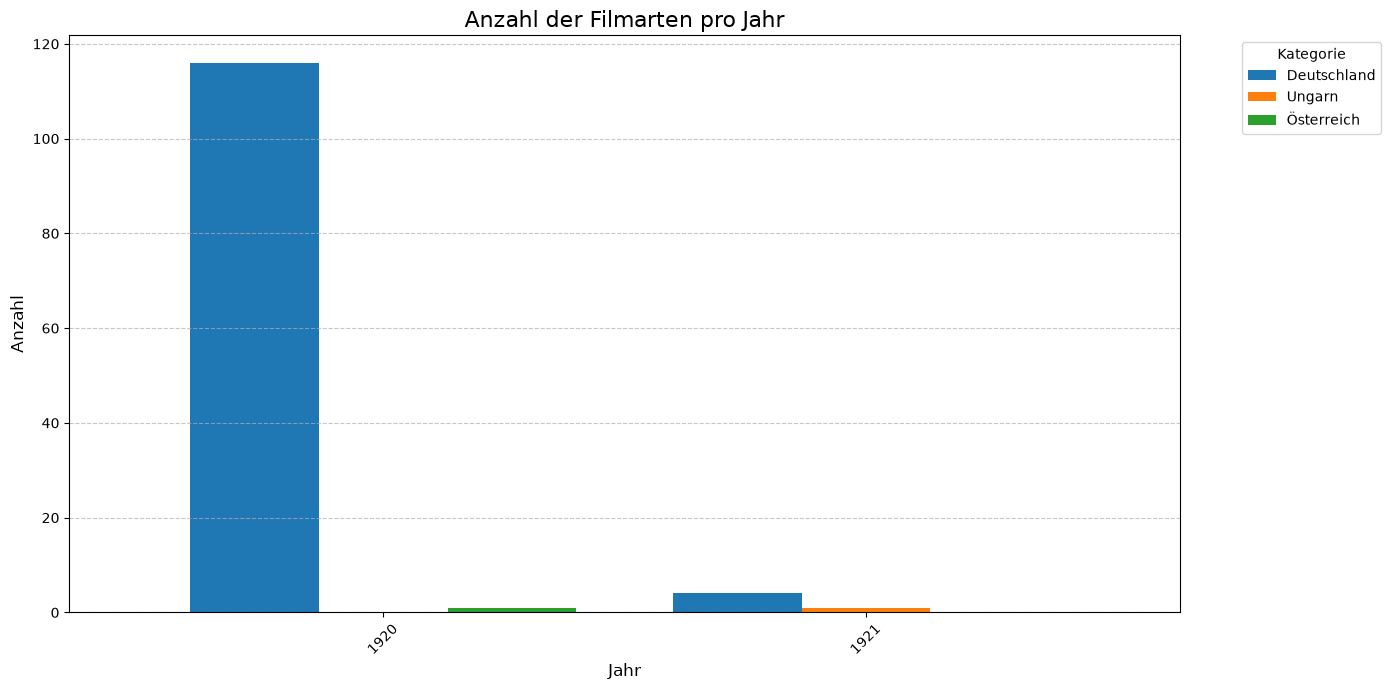

In [74]:
df_grouped = df.groupby(['Jahr', 'Land']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()
